In [31]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch_geometric.transforms import ToUndirected
from torch_geometric.nn import HeteroConv, SAGEConv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [32]:
data = torch.load("../data/processed/hetero_graph.pt")

print(data)

HeteroData(
  drug={ num_nodes=9875 },
  protein={ num_nodes=19425 },
  disease={ num_nodes=7687 },
  (drug, targets, protein)={ edge_index=[2, 26766] },
  (protein, interacts, protein)={ edge_index=[2, 472588] },
  (protein, associated_with, disease)={ edge_index=[2, 38959] }
)


In [33]:
data = ToUndirected()(data)

print(data.edge_index_dict.keys())

dict_keys([('drug', 'targets', 'protein'), ('protein', 'interacts', 'protein'), ('protein', 'associated_with', 'disease'), ('protein', 'rev_targets', 'drug'), ('disease', 'rev_associated_with', 'protein')])


In [34]:
embedding_dim = 64

data["drug"].x = torch.randn(data["drug"].num_nodes, embedding_dim)
data["protein"].x = torch.randn(data["protein"].num_nodes, embedding_dim)
data["disease"].x = torch.randn(data["disease"].num_nodes, embedding_dim)

print("Drug features:", data["drug"].x.shape)
print("Protein features:", data["protein"].x.shape)
print("Disease features:", data["disease"].x.shape)

Drug features: torch.Size([9875, 64])
Protein features: torch.Size([19425, 64])
Disease features: torch.Size([7687, 64])


In [35]:
#Extract Drug → Protein Edges


dp_edges = data["drug","targets","protein"].edge_index

dp_edges.shape

torch.Size([2, 26766])

In [36]:
#Extract Protein → Disease Edges

pd_edges = data["protein","associated_with","disease"].edge_index

pd_edges.shape

torch.Size([2, 38959])

In [37]:
dp_df = pd.DataFrame({
    "drug": dp_edges[0].numpy(),
    "protein": dp_edges[1].numpy()
})

pd_df = pd.DataFrame({
    "protein": pd_edges[0].numpy(),
    "disease": pd_edges[1].numpy()
})

dp_df.head()

,drug,protein
0,0,0
1,1,1
2,1,2
3,1,3
4,1,4


In [38]:
drug_disease_df = dp_df.merge(pd_df, on="protein")

print("Total candidate drug-disease pairs:", len(drug_disease_df))

drug_disease_df.head()

Total candidate drug-disease pairs: 497163


,drug,protein,disease
0,0,0,0
1,0,0,1
2,0,0,2
3,0,0,3
4,0,0,4


In [39]:
positive_edges = drug_disease_df[["drug","disease"]].drop_duplicates()

print("Positive drug-disease edges:", len(positive_edges))

positive_edges.head()

Positive drug-disease edges: 399449


,drug,disease
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4


In [40]:
train_pos, test_pos = train_test_split(
    positive_edges,
    test_size=0.2,
    random_state=42
)

print("Train positives:", len(train_pos))
print("Test positives:", len(test_pos))

Train positives: 319559
Test positives: 79890


In [41]:
#naegative sampling 
num_drugs = data["drug"].num_nodes
num_diseases = data["disease"].num_nodes

# number of negatives = positives
num_train_neg = len(train_pos)

neg_drugs = np.random.randint(0, num_drugs, num_train_neg)
neg_diseases = np.random.randint(0, num_diseases, num_train_neg)

train_neg = pd.DataFrame({
    "drug": neg_drugs,
    "disease": neg_diseases
})

print("Train negatives:", len(train_neg))

Train negatives: 319559


In [42]:
num_test_neg = len(test_pos)

neg_drugs = np.random.randint(0, num_drugs, num_test_neg)
neg_diseases = np.random.randint(0, num_diseases, num_test_neg)

test_neg = pd.DataFrame({
    "drug": neg_drugs,
    "disease": neg_diseases
})

print("Test negatives:", len(test_neg))

Test negatives: 79890


In [43]:
train_pos["label"] = 1
train_neg["label"] = 0

train_data = pd.concat([train_pos, train_neg], ignore_index=True)

train_data.head()

,drug,disease,label
0,1340,730,1
1,8248,1555,1
2,4047,359,1
3,5178,14,1
4,4322,86,1


In [44]:
test_pos["label"] = 1
test_neg["label"] = 0

test_data = pd.concat([test_pos, test_neg], ignore_index=True)

test_data.head()

,drug,disease,label
0,7583,1752,1
1,1533,852,1
2,785,281,1
3,1095,315,1
4,3353,3381,1


In [53]:
from torch_geometric.transforms import ToUndirected

data = ToUndirected()(data)

In [63]:
#Define Heterogeneous GNN


import torch.nn as nn
import torch.nn.functional as F

class HeteroGNN(nn.Module):

    def __init__(self, hidden_dim=128):
        super().__init__()

        self.conv1 = HeteroConv({
            ("drug","targets","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","rev_targets","drug"): SAGEConv((-1,-1), hidden_dim),
            ("protein","interacts","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","associated_with","disease"): SAGEConv((-1,-1), hidden_dim),
            ("disease","rev_associated_with","protein"): SAGEConv((-1,-1), hidden_dim),
        })

        self.conv2 = HeteroConv({
            ("drug","targets","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","rev_targets","drug"): SAGEConv((-1,-1), hidden_dim),
            ("protein","interacts","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","associated_with","disease"): SAGEConv((-1,-1), hidden_dim),
            ("disease","rev_associated_with","protein"): SAGEConv((-1,-1), hidden_dim),
        })

        self.conv3 = HeteroConv({
            ("drug","targets","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","rev_targets","drug"): SAGEConv((-1,-1), hidden_dim),
            ("protein","interacts","protein"): SAGEConv((-1,-1), hidden_dim),
            ("protein","associated_with","disease"): SAGEConv((-1,-1), hidden_dim),
            ("disease","rev_associated_with","protein"): SAGEConv((-1,-1), hidden_dim),
        })

        self.dropout = nn.Dropout(0.3)

    def forward(self, x_dict, edge_index_dict):

        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k,v in x_dict.items()}
        x_dict = {k: self.dropout(v) for k,v in x_dict.items()}

        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k,v in x_dict.items()}

        x_dict = self.conv3(x_dict, edge_index_dict)

        return x_dict

In [64]:
model = HeteroGNN(128)

print("Model initialized")

Model initialized


In [65]:
#Define Link Predictor


class LinkPredictor(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()

        self.lin1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, drug_emb, disease_emb):

        x = torch.cat([drug_emb, disease_emb], dim=-1)

        x = self.lin1(x)
        x = F.relu(x)

        x = self.lin2(x)

        return x

In [66]:
#Initialize Predictor + Optimizer


predictor = LinkPredictor(128)

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(predictor.parameters()),
    lr=0.003
)

loss_fn = torch.nn.BCEWithLogitsLoss()

print("Predictor ready")


Predictor ready


In [67]:
#Convert Train Dataset to Tensor


train_drugs = torch.tensor(train_data["drug"].values)
train_diseases = torch.tensor(train_data["disease"].values)
train_labels = torch.tensor(train_data["label"].values).float()

print(train_drugs.shape)

torch.Size([639118])


In [68]:
#Training Loop


epochs = 40
loss_history = []

for epoch in range(epochs):

    model.train()
    predictor.train()

    optimizer.zero_grad()

    # get node embeddings
    x_dict = model(data.x_dict, data.edge_index_dict)

    drug_emb = x_dict["drug"][train_drugs]
    disease_emb = x_dict["disease"][train_diseases]

    scores = predictor(drug_emb, disease_emb).squeeze()

    loss = loss_fn(scores, train_labels)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6944
Epoch 2, Loss: 0.6767
Epoch 3, Loss: 0.6413
Epoch 4, Loss: 0.7421
Epoch 5, Loss: 0.9265
Epoch 6, Loss: 0.6192
Epoch 7, Loss: 0.6152
Epoch 8, Loss: 0.6650
Epoch 9, Loss: 0.6509
Epoch 10, Loss: 0.6105
Epoch 11, Loss: 0.5943
Epoch 12, Loss: 0.5996
Epoch 13, Loss: 0.5986
Epoch 14, Loss: 0.5685
Epoch 15, Loss: 0.5313
Epoch 16, Loss: 0.5080
Epoch 17, Loss: 0.4911
Epoch 18, Loss: 0.4650
Epoch 19, Loss: 0.4473
Epoch 20, Loss: 0.4399
Epoch 21, Loss: 0.4211
Epoch 22, Loss: 0.4245
Epoch 23, Loss: 0.4066
Epoch 24, Loss: 0.4062
Epoch 25, Loss: 0.3860
Epoch 26, Loss: 0.3776
Epoch 27, Loss: 0.3700
Epoch 28, Loss: 0.3642
Epoch 29, Loss: 0.3579
Epoch 30, Loss: 0.3504
Epoch 31, Loss: 0.3535
Epoch 32, Loss: 0.3416
Epoch 33, Loss: 0.3430
Epoch 34, Loss: 0.3375
Epoch 35, Loss: 0.3304
Epoch 36, Loss: 0.3359
Epoch 37, Loss: 0.3299
Epoch 38, Loss: 0.3194
Epoch 39, Loss: 0.3235
Epoch 40, Loss: 0.3167


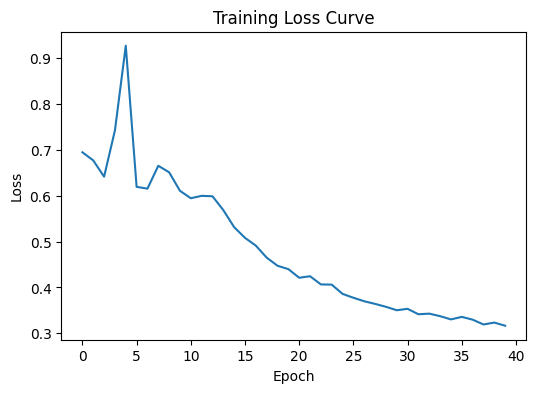

In [69]:
#Training Loss Curve (Report Figure)


plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [70]:
#Prepare Test Data


test_drugs = torch.tensor(test_data["drug"].values)
test_diseases = torch.tensor(test_data["disease"].values)
test_labels = torch.tensor(test_data["label"].values).float()

In [71]:
model.eval()
predictor.eval()

with torch.no_grad():

    x_dict = model(data.x_dict, data.edge_index_dict)

    drug_emb = x_dict["drug"][test_drugs]
    disease_emb = x_dict["disease"][test_diseases]

    scores = predictor(drug_emb, disease_emb).squeeze()

    probs = torch.sigmoid(scores).numpy()

    preds = (probs > 0.5).astype(int)

accuracy = accuracy_score(test_labels, preds)
roc_auc = roc_auc_score(test_labels, probs)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

Accuracy: 0.8687007134810364
ROC-AUC: 0.9424665546901931


In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(test_labels, preds)
recall = recall_score(test_labels, preds)
f1 = f1_score(test_labels, preds)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8687007134810364
ROC-AUC: 0.9424665546901931
Precision: 0.8263803477046837
Recall: 0.933533608711979
F1 Score: 0.8766949376686122


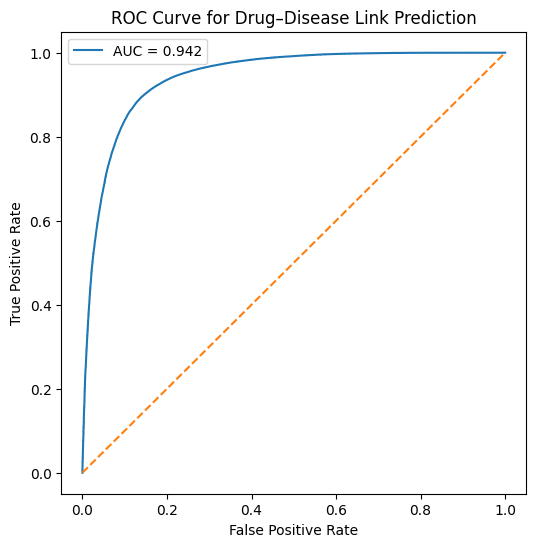

In [74]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_labels, probs)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Drug–Disease Link Prediction")

plt.legend()
plt.show()

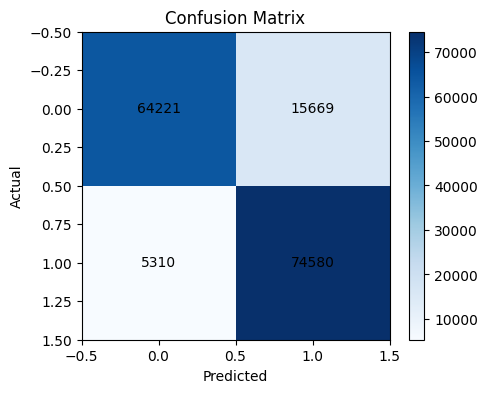

In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(5,4))

plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()